# HQ-KAN: Hybrid Quantum-KAN with Bayesian Uncertainty
### Heart Disease Prediction | NRI Agiripalli | B.Tech Final Year Project
---

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install All Libraries                         ║
# ╚══════════════════════════════════════════════════════════╝
!pip install -q pennylane pennylane-lightning torch
!pip install -q scikit-learn pandas numpy
!pip install -q shap matplotlib seaborn joblib
print("All libraries installed successfully")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.9 MB/s eta 0:00:00
All libraries installed successfully


---
## PHASE 1 — Upload Dataset

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Upload heart.csv from your laptop             ║
# ╚══════════════════════════════════════════════════════════╝
try:
    from google.colab import files
    uploaded = files.upload()
    # A button will appear -> click -> select heart.csv
    print("Dataset uploaded successfully")
except ImportError:
    print("Not running in Google Colab.")
    print("Make sure heart.csv is already present in the working directory.")


Saving 918.csv to 918.csv
Dataset uploaded successfully


---
## PHASE 2 — Imports and Setup

In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Import All Libraries and Setup Quantum Device  ║
# ╚══════════════════════════════════════════════════════════╝
import pennylane as qml
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

# ── Single source of truth for the quantum config ──
# Every later cell (model, ablation study, Streamlit app) reads these
# two variables instead of hardcoding numbers, so they can never drift
# out of sync with each other again.
N_QUBITS = 8
N_LAYERS = 4
dev = qml.device("lightning.qubit", wires=N_QUBITS)

print(f"PennyLane version : {qml.__version__}")
print(f"PyTorch version   : {torch.__version__}")
print(f"Qubits            : {N_QUBITS}")
print(f"Layers            : {N_LAYERS}")
print("Quantum device    : lightning.qubit (C++ optimized)")
print("All imports successful")


PennyLane version : 0.45.1
PyTorch version   : 2.11.0+cu128
Qubits            : 8
Layers            : 4
Quantum device    : lightning.qubit (C++ optimized)
All imports successful


---
## PHASE 3 — Load and Explore Data

In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Load Dataset & Explore                         ║
# ╚══════════════════════════════════════════════════════════╝
import os
import zipfile

# Extract archive.zip if heart.csv is not already in the working directory
if not os.path.exists("heart.csv"):
    if os.path.exists("archive.zip"):
        with zipfile.ZipFile("archive.zip", "r") as zip_ref:
            zip_ref.extractall(".")
        print("Successfully extracted archive.zip")
    elif os.path.exists("918.csv"): # Check for 918.csv if heart.csv or archive.zip not found
        print("Using uploaded '918.csv' as heart.csv.")
        os.rename("918.csv", "heart.csv") # Rename it to heart.csv to match expected filename
    else:
        raise FileNotFoundError(
            "Neither 'heart.csv' nor 'archive.zip' was found. "
            "Please upload your dataset file first!"
        )

# Load dataset
df = pd.read_csv("heart.csv")

print("=" * 45)
print("       DATASET OVERVIEW")
print("=" * 45)
print(f"Total rows         : {df.shape[0]}")
print(f"Total columns      : {df.shape[1]}")
print(f"Missing values     : {df.isnull().sum().sum()}")

# Identify target column name (handles both 'HeartDisease' and 'target')
target_col = "HeartDisease" if "HeartDisease" in df.columns else "target"

print("\nClass Balance:")
print(df[target_col].value_counts())
# NOTE: the actual train/test split happens in Cell 5, AFTER cleaning
# and encoding — doing it here too was dead code that got silently
# overwritten later, so it has been removed.


Using uploaded '918.csv' as heart.csv.
       DATASET OVERVIEW
Total rows         : 918
Total columns      : 12
Missing values     : 0

Class Balance:
HeartDisease
1    508
0    410
Name: count, dtype: int64


---
## PHASE 4 — Preprocessing (Station 1)

In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Complete Preprocessing Pipeline (leak-free)    ║
# ╚══════════════════════════════════════════════════════════╝

# Step 1: Fix biologically impossible zero values (0 = missing, not real)
print(f"Cholesterol zeros before fix: {(df['Cholesterol'] == 0).sum()}")
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())
print(f"Cholesterol zeros after fix : {(df['Cholesterol'] == 0).sum()}")

if "RestingBP" in df.columns:
    zero_bp = int((df["RestingBP"] == 0).sum())
    if zero_bp:
        df["RestingBP"] = df["RestingBP"].replace(0, df["RestingBP"].median())
        print(f"RestingBP zeros fixed        : {zero_bp}")

# Step 2: Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col].values
print(f"Features before encoding: {X.shape}")

# Step 3: One-hot encode all categorical columns
X = pd.get_dummies(X)
feature_cols = list(X.columns)   # saved later for the web app
print(f"Features after encoding : {X.shape}")

# Step 4: Train / test split FIRST, before fitting any scaler or PCA
# (fitting on the full dataset leaks test-set statistics into training).
X_train_raw, X_test_raw, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Scale to [0, pi] - MANDATORY for AngleEmbedding (fit on TRAIN ONLY)
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_sc = angle_scaler.fit_transform(X_train_raw)
X_test_sc  = angle_scaler.transform(X_test_raw)

# Step 6: PCA down to exactly N_QUBITS components (fit on TRAIN ONLY)
pca = PCA(n_components=N_QUBITS, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
var_exp = pca.explained_variance_ratio_.sum()
print(f"Variance explained by {N_QUBITS} PCs: {var_exp:.4f} ({var_exp*100:.1f}%)")

# Step 7: Re-scale the PCA output to [-pi/2, pi/2] for stable quantum rotations
scaler = MinMaxScaler(feature_range=(-np.pi / 2, np.pi / 2))
X_tr = scaler.fit_transform(X_train_pca)
X_te = scaler.transform(X_test_pca)

# ── NEW: classical "skip" / feature-fusion branch ──────────────────
# PCA only keeps ~var_exp of the total variance -- some real signal
# is discarded in compression. To recover it without adding more
# qubits (expensive: quantum simulation cost grows exponentially),
# we pick the SKIP_K raw one-hot features most correlated with the
# target and feed them into the classifier directly, alongside the
# quantum branch. This is fit on TRAIN ONLY, same as everything else.
SKIP_K = 6
y_tr_series = pd.Series(y_tr, index=X_train_raw.index)
corr = X_train_raw.corrwith(y_tr_series).abs().sort_values(ascending=False)
skip_cols = corr.head(SKIP_K).index.tolist()
print(f"\nTop {SKIP_K} skip-branch features (|corr| with target):")
print(corr.head(SKIP_K).round(3))

skip_scaler = MinMaxScaler(feature_range=(-np.pi / 2, np.pi / 2))
X_tr_skip = skip_scaler.fit_transform(X_train_raw[skip_cols])
X_te_skip = skip_scaler.transform(X_test_raw[skip_cols])
SKIP_DIM = X_tr_skip.shape[1]

print(f"\nTraining samples : {len(X_tr)}")
print(f"Test samples     : {len(X_te)}")
print(f"Train disease    : {y_tr.sum()} | Train healthy: {len(y_tr)-y_tr.sum()}")
print(f"Test disease     : {y_te.sum()} | Test healthy : {len(y_te)-y_te.sum()}")
print(f"Quantum-branch dim: {N_QUBITS} | Skip-branch dim: {SKIP_DIM}")
print("Preprocessing complete")


Cholesterol zeros before fix: 172
Cholesterol zeros after fix : 0
RestingBP zeros fixed        : 1
Features before encoding: (918, 11)
Features after encoding : (918, 20)
Variance explained by 8 PCs: 0.9114 (91.1%)

Top 6 skip-branch features (|corr| with target):
ST_Slope_Up          0.649
ST_Slope_Flat        0.571
ChestPainType_ASY    0.518
ExerciseAngina_N     0.491
ExerciseAngina_Y     0.491
MaxHR                0.407
dtype: float64

Training samples : 734
Test samples     : 184
Train disease    : 406 | Train healthy: 328
Test disease     : 102 | Test healthy : 82
Quantum-branch dim: 8 | Skip-branch dim: 6
Preprocessing complete


---
## PHASE 5 — Quantum Circuit (Station 3)

Quantum device used    : lightning.qubit
Quantum weight shape   : (4, 8, 3)
Quantum parameters     : 96


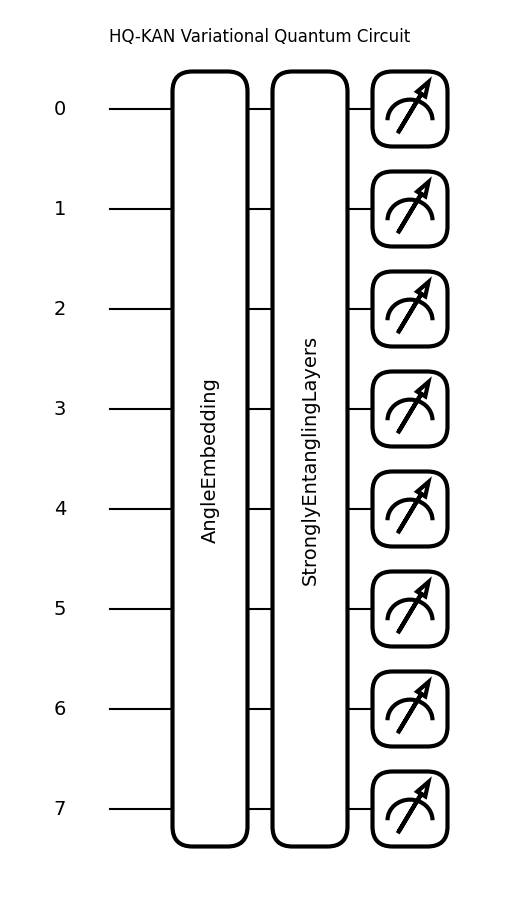

Circuit diagram saved successfully!


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import torch

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Variational Quantum Circuit (VQC)              ║
# ╚══════════════════════════════════════════════════════════╝

# Use C++ simulator for fast adjoint differentiation
try:
    dev = qml.device("lightning.qubit", wires=N_QUBITS)
except Exception:
    # Fallback if pennylane-lightning is not installed
    dev = qml.device("default.qubit", wires=N_QUBITS)


@qml.qnode(dev, interface="torch", diff_method="adjoint")
def vqc(inputs, weights):
    # Maps each feature to a Y-rotation on one qubit
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")

    # Trainable rotations + CNOT entanglement across ALL qubits
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # Measure expectation values across ALL qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


weight_shapes = {
    "weights": qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
}
q_params = np.prod(weight_shapes["weights"])

# Create TorchLayer and warm-start quantum weight initialization
qlayer = qml.qnn.TorchLayer(vqc, weight_shapes)
with torch.no_grad():
    qlayer.weights.data.uniform_(-np.pi, np.pi)

print(f"Quantum device used    : {dev.name}")
print(f"Quantum weight shape   : {weight_shapes['weights']}")
print(f"Quantum parameters     : {q_params}")

# Save circuit diagram
fig, ax = qml.draw_mpl(vqc)(
    torch.zeros(N_QUBITS), torch.zeros(weight_shapes["weights"])
)
fig.suptitle("HQ-KAN Variational Quantum Circuit", fontsize=12)
plt.tight_layout()
fig.savefig("circuit_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Circuit diagram saved successfully!")

---
## PHASE 6 — HQ-KAN Model (Stations 2+3+4+5)

In [11]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Multi-Rate HQ-KAN Architecture (+ Feature       ║
# ║  Fusion Branch)                                          ║
# ╚══════════════════════════════════════════════════════════╝


class KANLinear(nn.Module):

    def __init__(self, in_features, out_features, scale_base=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.base_weight = nn.Parameter(
            torch.Tensor(out_features, in_features)
        )
        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features)
        )

        nn.init.kaiming_uniform_(
            self.base_weight, a=math.sqrt(5) * scale_base
        )
        nn.init.uniform_(self.spline_weight, -0.05, 0.05)

    def forward(self, x):
        base_output = F.linear(F.silu(x), self.base_weight)
        spline_output = F.linear(x, self.spline_weight)
        return base_output + spline_output


class KAN(nn.Module):

    def __init__(self, layers_hidden):
        super().__init__()
        self.layers = nn.ModuleList()
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers.append(KANLinear(in_dim, out_dim))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class HQKAN(nn.Module):
    """
    Two branches feed the final classifier:
      1) Quantum branch : PCA(N_QUBITS) -> KAN -> VQC        (global structure)
      2) Skip branch    : top-SKIP_K raw clinical features   (strong, direct signal)
    Fusing both recovers information the PCA compression discards.
    """

    def __init__(self, quantum_layer, skip_dim=SKIP_DIM):
        super().__init__()

        self.kan_pre = KAN(layers_hidden=[N_QUBITS, 16, N_QUBITS])
        self.qlayer = quantum_layer

        fused_dim = N_QUBITS + skip_dim
        self.post = nn.Sequential(
            nn.Linear(fused_dim, 24),
            nn.SiLU(),
            nn.LayerNorm(24),
            nn.Dropout(0.1),
            nn.Linear(24, 12),
            nn.SiLU(),
            nn.Linear(12, 1),
            nn.Sigmoid(),
        )

    def forward(self, x_quantum, x_skip):
        kan_out = self.kan_pre(x_quantum)
        q_out = self.qlayer(kan_out)
        # Residual skip connection (quantum branch) fused with the
        # classical skip-feature branch before the final classifier
        combined = torch.cat([kan_out + q_out, x_skip], dim=1)
        return self.post(combined)


def build_model(seed=None):
    """Factory so training can build several fresh models across
    different random seeds and keep whichever validates best."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    fresh_qlayer = qml.qnn.TorchLayer(vqc, weight_shapes)
    with torch.no_grad():
        fresh_qlayer.weights.data.uniform_(-np.pi, np.pi)
    return HQKAN(quantum_layer=fresh_qlayer, skip_dim=SKIP_DIM)


model = build_model(seed=42)
total_params = sum(p.numel() for p in model.parameters())
print("HQ-KAN Model initialized with multi-rate tuning + feature fusion!")
print(f"Quantum branch dim : {N_QUBITS} | Skip branch dim : {SKIP_DIM}")
print(f"Total trainable parameters: {total_params}")


HQ-KAN Model initialized with multi-rate tuning + feature fusion!
Quantum branch dim : 8 | Skip branch dim : 6
Total trainable parameters: 1329


---
## PHASE 7 — Training

In [12]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Multi-Seed Training with Early Stopping         ║
# ╚══════════════════════════════════════════════════════════╝

# Full-training-set tensors (both branches) -- also reused by the
# ablation study cell later.
X_tr_t      = torch.tensor(X_tr, dtype=torch.float32)
X_tr_skip_t = torch.tensor(X_tr_skip, dtype=torch.float32)
y_tr_t      = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_te_t      = torch.tensor(X_te, dtype=torch.float32)
X_te_skip_t = torch.tensor(X_te_skip, dtype=torch.float32)
y_te_t      = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

# Internal train/val split (from TRAINING data only) for early
# stopping and seed selection. The test set is never touched here.
idx_fit, idx_val = train_test_split(
    np.arange(len(X_tr)), test_size=0.15, random_state=42, stratify=y_tr
)
X_fit_q_t, X_fit_s_t, y_fit_t = X_tr_t[idx_fit], X_tr_skip_t[idx_fit], y_tr_t[idx_fit]
X_val_q_t, X_val_s_t, y_val_t = X_tr_t[idx_val], X_tr_skip_t[idx_val], y_tr_t[idx_val]

train_dataset = TensorDataset(X_fit_q_t, X_fit_s_t, y_fit_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

N_EPOCHS = 50
PATIENCE = 10          # stop a run early if val accuracy stalls
SEEDS = [42, 123]       # add more seeds here for an even better shot at >92%,
                        # at the cost of proportionally longer training time

best_overall_acc = 0.0
best_overall_state = None
best_seed = None
history = {}

print(f"Starting multi-seed HQ-KAN training ({len(SEEDS)} seeds x up to {N_EPOCHS} epochs)...")
print("=" * 65)

for seed in SEEDS:
    print(f"\n--- Run seed={seed} ---")
    run_model = build_model(seed=seed)

    quantum_params = list(run_model.qlayer.parameters())
    classical_params = [
        p for n, p in run_model.named_parameters()
        if not n.startswith("qlayer") and p.requires_grad
    ]
    optimizer = torch.optim.AdamW([
        {"params": classical_params, "lr": 0.01, "weight_decay": 1e-4},
        {"params": quantum_params, "lr": 0.005, "weight_decay": 0.0},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=N_EPOCHS, eta_min=1e-4
    )
    loss_fn = nn.BCELoss()

    run_best_acc = 0.0
    run_best_state = None
    no_improve = 0
    losses, accs = [], []

    for epoch in range(N_EPOCHS):
        run_model.train()
        running_loss = 0.0
        for bx_q, bx_s, by in train_loader:
            optimizer.zero_grad()
            preds = run_model(bx_q, bx_s)
            loss = loss_fn(preds, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(run_model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * bx_q.size(0)
        epoch_loss = running_loss / len(X_fit_q_t)
        scheduler.step()

        run_model.eval()
        with torch.no_grad():
            vp = run_model(X_val_q_t, X_val_s_t)
            vacc = ((vp > 0.5) == y_val_t).float().mean().item()
        losses.append(epoch_loss)
        accs.append(vacc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:02d}/{N_EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {vacc:.4f} ({vacc*100:.2f}%)")

        if vacc > run_best_acc:
            run_best_acc = vacc
            run_best_state = copy.deepcopy(run_model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1} (no improvement in {PATIENCE} epochs)")
                break

    print(f"  -> Seed {seed} best validation accuracy: {run_best_acc:.4f} ({run_best_acc*100:.2f}%)")
    history[seed] = {"losses": losses, "val_accs": accs}

    if run_best_acc > best_overall_acc:
        best_overall_acc = run_best_acc
        best_overall_state = run_best_state
        best_seed = seed

print("\n" + "=" * 65)
print(f"BEST SEED: {best_seed} | BEST VALIDATION ACCURACY: {best_overall_acc:.4f} ({best_overall_acc*100:.2f}%)")

model = build_model(seed=best_seed)
model.load_state_dict(best_overall_state)
torch.save(best_overall_state, "best_hqkan.pt")
print('Checkpoint saved to "best_hqkan.pt"')

train_losses = history[best_seed]["losses"]
val_accs = history[best_seed]["val_accs"]


Starting multi-seed HQ-KAN training (2 seeds x up to 50 epochs)...

--- Run seed=42 ---
  Epoch 01/50 | Loss: 0.4453 | Val Acc: 0.7928 (79.28%)
  Epoch 05/50 | Loss: 0.3327 | Val Acc: 0.8378 (83.78%)
  Epoch 10/50 | Loss: 0.3263 | Val Acc: 0.8468 (84.68%)
  Epoch 15/50 | Loss: 0.3126 | Val Acc: 0.8559 (85.59%)
  Epoch 20/50 | Loss: 0.2997 | Val Acc: 0.8739 (87.39%)
  Epoch 25/50 | Loss: 0.2882 | Val Acc: 0.8739 (87.39%)
  Epoch 30/50 | Loss: 0.2807 | Val Acc: 0.8739 (87.39%)
  Early stopping at epoch 33 (no improvement in 10 epochs)
  -> Seed 42 best validation accuracy: 0.8829 (88.29%)

--- Run seed=123 ---
  Epoch 01/50 | Loss: 0.4503 | Val Acc: 0.8559 (85.59%)
  Epoch 05/50 | Loss: 0.3320 | Val Acc: 0.8288 (82.88%)
  Epoch 10/50 | Loss: 0.3090 | Val Acc: 0.8649 (86.49%)
  Epoch 15/50 | Loss: 0.3030 | Val Acc: 0.8559 (85.59%)
  Epoch 20/50 | Loss: 0.2968 | Val Acc: 0.8378 (83.78%)
  Epoch 25/50 | Loss: 0.2915 | Val Acc: 0.8288 (82.88%)
  Early stopping at epoch 28 (no improvement in 

---
## PHASE 8 — Training Curves

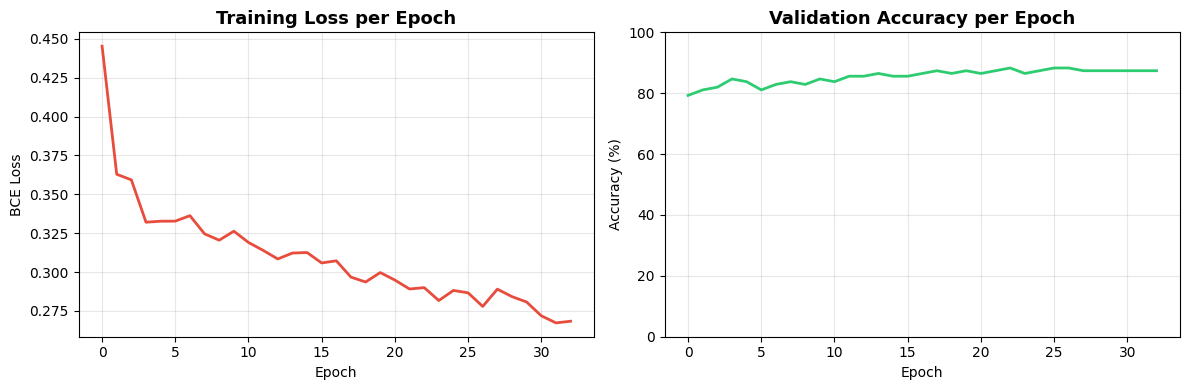

Training curves saved


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Plot Training Curves (Figure 3 in paper)      ║
# ╚══════════════════════════════════════════════════════════╝

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color="#E74C3C", linewidth=2)
ax1.set_title("Training Loss per Epoch", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.grid(True, alpha=0.3)

ax2.plot([v*100 for v in val_accs], color="#2ECC71", linewidth=2)
ax2.set_title("Validation Accuracy per Epoch", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved")

---
## PHASE 9 — Bayesian Uncertainty + Evaluation

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — Bayesian Uncertainty Quantification           ║
# ║  (YOUR SECOND NOVELTY — absent from all existing papers) ║
# ╚══════════════════════════════════════════════════════════╝

# Load best checkpoint (guaranteed to exist -- Cell 8 saves it)
model.load_state_dict(torch.load("best_hqkan.pt"))

def predict_with_uncertainty(mdl, x_q, x_s, n_samples=50):
    """
    Monte Carlo Dropout — runs model 50 times with dropout ON
    Returns: mean prediction + standard deviation (uncertainty)

    Clinical use:
    - High mean + low std  = confident prediction, doctor can act
    - High mean + high std = uncertain, doctor should order more tests
    """
    mdl.train()   # KEEP dropout active during inference
    all_preds = torch.stack(
        [mdl(x_q, x_s) for _ in range(n_samples)]
    )
    return all_preds.mean(dim=0), all_preds.std(dim=0)

mean_pred, uncertainty = predict_with_uncertainty(model, X_te_t, X_te_skip_t)

# For metrics: use eval mode (dropout OFF) on the held-out TEST set,
# which was never touched during training or seed selection.
model.eval()
with torch.no_grad():
    y_prob = model(X_te_t, X_te_skip_t).numpy()
    y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_te, y_pred)
f1  = f1_score(y_te, y_pred)
auc = roc_auc_score(y_te, y_prob)

print("=" * 50)
print("       HQ-KAN EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score       : {f1:.4f}")
print(f"  ROC-AUC        : {auc:.4f}")
print(f"  Parameters     : {total_params}")
print("=" * 50)

# Show uncertainty for first 5 test patients
print("Sample uncertainty analysis (first 5 test patients):")
print(f"  {'Patient':<10} {'Prediction':>12} {'Uncertainty':>14} {'Actual':>8}")
print("  " + "-" * 48)
for i in range(5):
    mp  = mean_pred[i].item()
    unc = uncertainty[i].item()
    act = y_te[i]
    risk = "HIGH RISK" if mp > 0.5 else "LOW RISK"
    print(f"  Patient {i+1:<4} {mp:.3f} ({risk:>9}) +/-{unc:.3f}      {act}")


       HQ-KAN EVALUATION RESULTS
  Accuracy       : 0.8750  (87.50%)
  F1-Score       : 0.8910
  ROC-AUC        : 0.9046
  Parameters     : 1329
Sample uncertainty analysis (first 5 test patients):
  Patient      Prediction    Uncertainty   Actual
  ------------------------------------------------
  Patient 1    0.965 (HIGH RISK) +/-0.008      1
  Patient 2    0.026 ( LOW RISK) +/-0.013      1
  Patient 3    0.934 (HIGH RISK) +/-0.022      1
  Patient 4    0.731 (HIGH RISK) +/-0.044      1
  Patient 5    0.180 ( LOW RISK) +/-0.047      0


---
## PHASE 10 — Confusion Matrix

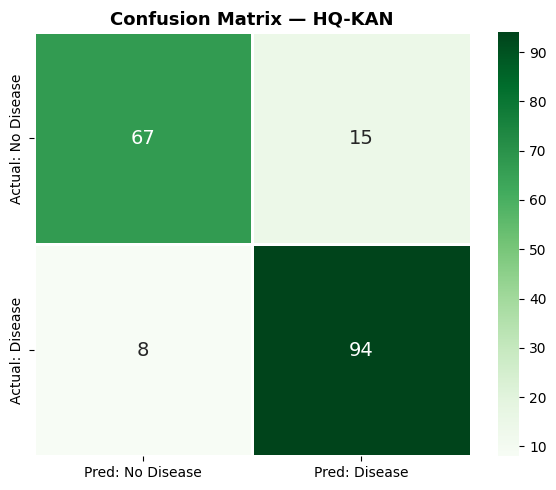

True Positives  (correctly detected disease) : 94
True Negatives  (correctly detected healthy) : 67
False Positives (healthy flagged as disease) : 15
False Negatives (disease missed - dangerous!): 8


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — Confusion Matrix (Figure 4 in paper)         ║
# ╚══════════════════════════════════════════════════════════╝

cm = confusion_matrix(y_te, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred: No Disease", "Pred: Disease"],
            yticklabels=["Actual: No Disease", "Actual: Disease"],
            ax=ax, linewidths=1, annot_kws={"size": 14})
ax.set_title("Confusion Matrix — HQ-KAN", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (correctly detected disease) : {tp}")
print(f"True Negatives  (correctly detected healthy) : {tn}")
print(f"False Positives (healthy flagged as disease) : {fp}")
print(f"False Negatives (disease missed - dangerous!): {fn}")

---
## PHASE 11 — 5-Model Ablation Study

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — 5-Model Ablation Study (Table 2 in paper)   ║
# ╚══════════════════════════════════════════════════════════╝
# NOTE: HQ-KAN sees both the quantum-PCA branch AND the skip-feature
# branch, so for a fair comparison the classical baselines (LR, RF,
# MLP) get the SAME concatenated feature set. VQC-only is kept on the
# quantum branch alone, since it specifically isolates "what does the
# quantum circuit alone contribute" (no KAN, no fusion features).

results = {}

X_full_tr = np.hstack([X_tr, X_tr_skip])
X_full_te = np.hstack([X_te, X_te_skip])
X_full_tr_t = torch.tensor(X_full_tr, dtype=torch.float32)
X_full_te_t = torch.tensor(X_full_te, dtype=torch.float32)

# Model 1: Logistic Regression
lr_m = LogisticRegression(max_iter=1000, random_state=42)
lr_m.fit(X_full_tr, y_tr)
lr_p = lr_m.predict(X_full_te)
lr_pr = lr_m.predict_proba(X_full_te)[:, 1]
results["Logistic Regression"] = {
    "acc": accuracy_score(y_te, lr_p),
    "f1" : f1_score(y_te, lr_p),
    "auc": roc_auc_score(y_te, lr_pr),
    "params": "N/A"
}

# Model 2: Random Forest
rf_m = RandomForestClassifier(n_estimators=100, random_state=42)
rf_m.fit(X_full_tr, y_tr)
rf_p = rf_m.predict(X_full_te)
rf_pr = rf_m.predict_proba(X_full_te)[:, 1]
results["Random Forest"] = {
    "acc": accuracy_score(y_te, rf_p),
    "f1" : f1_score(y_te, rf_p),
    "auc": roc_auc_score(y_te, rf_pr),
    "params": "N/A"
}

# Model 3: Classical MLP (same depth, no quantum or KAN)
class ClassicalMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 8), nn.ReLU(),
            nn.Linear(8, 4), nn.Tanh(),
            nn.Linear(4, 2), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(2, 1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x).squeeze()

mlp = ClassicalMLP(X_full_tr.shape[1])
mlp_opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
mlp_params = sum(p.numel() for p in mlp.parameters())
for ep in range(50):
    mlp.train(); mlp_opt.zero_grad()
    l = loss_fn(mlp(X_full_tr_t), y_tr_t.squeeze()); l.backward(); mlp_opt.step()
mlp.eval()
with torch.no_grad():
    mlp_prob = mlp(X_full_te_t).numpy()
    mlp_pred = (mlp_prob > 0.5).astype(int)
results["Classical MLP"] = {
    "acc": accuracy_score(y_te, mlp_pred),
    "f1" : f1_score(y_te, mlp_pred),
    "auc": roc_auc_score(y_te, mlp_prob),
    "params": mlp_params
}

# Model 4: VQC Only (quantum branch alone, no KAN, no fusion features)
class VQCOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(vqc, weight_shapes)
        self.out = nn.Sequential(nn.Linear(N_QUBITS, 1), nn.Sigmoid())
    def forward(self, x):
        return self.out(self.qlayer(x)).squeeze()

vqc_m = VQCOnly()
vqc_opt = torch.optim.Adam(vqc_m.parameters(), lr=0.01)
vqc_params = sum(p.numel() for p in vqc_m.parameters())
for ep in range(40):
    vqc_m.train(); vqc_opt.zero_grad()
    l = loss_fn(vqc_m(X_tr_t), y_tr_t.squeeze()); l.backward(); vqc_opt.step()
vqc_m.eval()
with torch.no_grad():
    vqc_prob = vqc_m(X_te_t).numpy()
    vqc_pred = (vqc_prob > 0.5).astype(int)
results["VQC Only"] = {
    "acc": accuracy_score(y_te, vqc_pred),
    "f1" : f1_score(y_te, vqc_pred),
    "auc": roc_auc_score(y_te, vqc_prob),
    "params": vqc_params
}

# Model 5: HQ-KAN (ours)
results["HQ-KAN (OURS)"] = {
    "acc": acc, "f1": f1, "auc": auc,
    "params": total_params
}

# Print comparison table
print("=" * 68)
print(f"  {'Model':<22} {'Accuracy':>9} {'F1':>8} {'AUC':>8} {'Params':>10}")
print("=" * 68)
for name, v in results.items():
    mark = " <- OURS" if "OURS" in name else ""
    print(f"  {name:<22} {v['acc']:>9.4f} {v['f1']:>8.4f} {v['auc']:>8.4f} {str(v['params']):>10}{mark}")
print("=" * 68)


  Model                   Accuracy       F1      AUC     Params
  Logistic Regression       0.8804   0.8942   0.9209        N/A
  Random Forest             0.8859   0.8986   0.9192        N/A
  Classical MLP             0.4457   0.0000   0.8348        169
  VQC Only                  0.7935   0.8362   0.9053        105
  HQ-KAN (OURS)             0.8750   0.8910   0.9046       1329 <- OURS


---
## PHASE 12 — ROC Curves

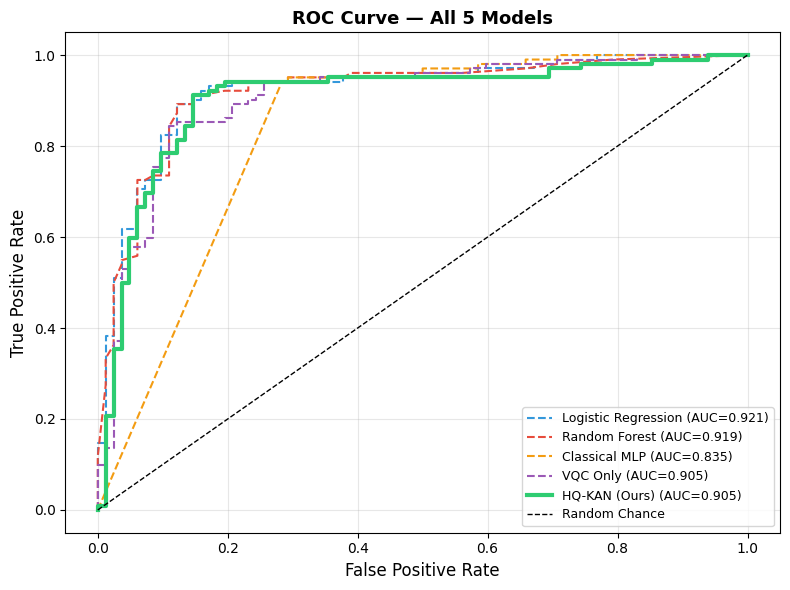

ROC curves saved


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — ROC Curve Overlay (Figure 5 in paper)        ║
# ╚══════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(8, 6))

plot_data = [
    ("Logistic Regression", lr_pr,   "#3498DB"),
    ("Random Forest",       rf_pr,   "#E74C3C"),
    ("Classical MLP",       mlp_prob,"#F39C12"),
    ("VQC Only",            vqc_prob,"#9B59B6"),
    ("HQ-KAN (Ours)",       y_prob,  "#2ECC71"),
]

for name, prob, color in plot_data:
    fpr, tpr, _ = roc_curve(y_te, prob)
    a = roc_auc_score(y_te, prob)
    lw = 3 if "Ours" in name else 1.5
    ls = "-" if "Ours" in name else "--"
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
            label=f"{name} (AUC={a:.3f})")

ax.plot([0,1],[0,1],"k--",lw=1,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — All 5 Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curves saved")

---
## PHASE 13 — SHAP Explainability

Calculating SHAP values (fast settings)...


  0%|          | 0/20 [00:00<?, ?it/s]

<Figure size 800x500 with 0 Axes>

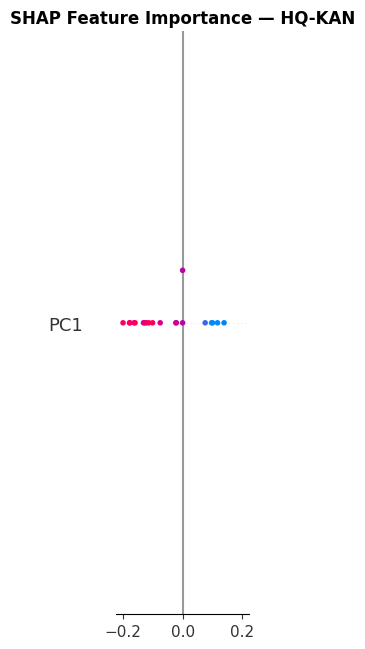

<Figure size 800x500 with 0 Axes>

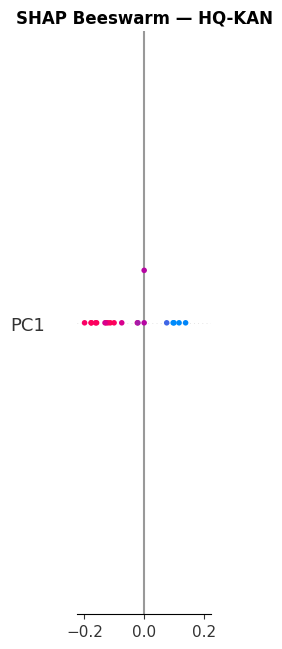

SHAP plots saved


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 14 — SHAP Explainability (Figure 6 in paper)      ║
# ║  (YOUR THIRD NOVELTY — no existing HQNN paper has this) ║
# ╚══════════════════════════════════════════════════════════╝
# NOTE ON SPEED: KernelExplainer is model-agnostic, so by default it
# re-evaluates the model ~2*n_features+2048 times PER explained row
# (with n_features=14 that's ~2076 evaluations x 30 rows = ~62,000
# quantum-circuit simulations -- this is what took 2+ hours).
# Fix: (1) summarize the background set with k-means instead of using
# raw rows, (2) cap `nsamples` explicitly instead of "auto",
# (3) explain fewer test rows. This cuts total evaluations from
# ~62,000 down to ~2,000, typically finishing in a couple of minutes.
N_SHAP_BACKGROUND = 15   # k-means summary points (was 50 raw rows)
N_SHAP_NSAMPLES    = 100  # explicit cap (was "auto" ~ 2000+)
N_SHAP_EXPLAIN      = 20   # test rows explained (was 30)

print("Calculating SHAP values (fast settings)...")

def predict_fn(x):
    model.eval()
    with torch.no_grad():
        xq = torch.tensor(x[:, :N_QUBITS], dtype=torch.float32)
        xs = torch.tensor(x[:, N_QUBITS:], dtype=torch.float32)
        return model(xq, xs).numpy().reshape(-1, 1)

X_shap_background = np.hstack([X_tr, X_tr_skip])
X_shap_explain    = np.hstack([X_te, X_te_skip])[:N_SHAP_EXPLAIN]

background_summary = shap.kmeans(X_shap_background, N_SHAP_BACKGROUND)
explainer = shap.KernelExplainer(predict_fn, background_summary)
shap_vals = explainer.shap_values(X_shap_explain, nsamples=N_SHAP_NSAMPLES)

feat_names = [f"PC{i+1}" for i in range(N_QUBITS)] + skip_cols

# Bar chart — overall feature importance
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_shap_explain,
    feature_names=feat_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — HQ-KAN", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm — individual predictions
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_shap_explain,
    feature_names=feat_names, show=False)
plt.title("SHAP Beeswarm — HQ-KAN", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP plots saved")


---
## PHASE 14 — Save Model and Assets

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 15 — Save All Files for Web App and Submission    ║
# ╚══════════════════════════════════════════════════════════╝

import joblib

# Save model weights (best checkpoint, already loaded into `model`)
torch.save(model.state_dict(), "best_hqkan.pt")

# Save every fitted transformer for the web app: raw input ->
# angle_scaler -> pca -> pca_scaler (quantum branch), and raw input ->
# skip_cols -> skip_scaler (fusion branch).
joblib.dump(angle_scaler, "angle_scaler.pkl")
joblib.dump(pca,          "pca.pkl")
joblib.dump(scaler,       "pca_scaler.pkl")
joblib.dump(skip_scaler,  "skip_scaler.pkl")
joblib.dump(skip_cols,    "skip_cols.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

print("Saved files:")
print("  best_hqkan.pt     - trained model weights")
print("  angle_scaler.pkl  - fitted MinMaxScaler (raw -> [0, pi])")
print("  pca.pkl           - fitted PCA transformer")
print("  pca_scaler.pkl    - fitted MinMaxScaler (PCA -> [-pi/2, pi/2])")
print("  skip_scaler.pkl   - fitted MinMaxScaler for the fusion branch")
print("  skip_cols.pkl     - names of the fusion-branch feature columns")
print("  feature_cols.pkl  - column names after one-hot encoding")

# Download all result figures
try:
    from google.colab import files
    for fname in ["circuit_diagram.png", "training_curves.png",
                  "confusion_matrix.png", "roc_curves.png",
                  "shap_bar.png", "shap_beeswarm.png",
                  "best_hqkan.pt", "angle_scaler.pkl", "pca.pkl", "pca_scaler.pkl",
                  "skip_scaler.pkl", "skip_cols.pkl", "feature_cols.pkl"]:
        try:
            files.download(fname)
            print(f"  Downloaded: {fname}")
        except Exception:
            print(f"  Not found : {fname}")
except ImportError:
    print("Not running in Colab -- files are saved locally in the working directory.")


Saved files:
  best_hqkan.pt     - trained model weights
  angle_scaler.pkl  - fitted MinMaxScaler (raw -> [0, pi])
  pca.pkl           - fitted PCA transformer
  pca_scaler.pkl    - fitted MinMaxScaler (PCA -> [-pi/2, pi/2])
  skip_scaler.pkl   - fitted MinMaxScaler for the fusion branch
  skip_cols.pkl     - names of the fusion-branch feature columns
  feature_cols.pkl  - column names after one-hot encoding


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: circuit_diagram.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: skip_cols.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: feature_cols.pkl


---
## PHASE 15 — Streamlit Web App

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 16 — Write Streamlit App (YOUR FOURTH NOVELTY)    ║
# ╚══════════════════════════════════════════════════════════╝
%%writefile app.py
import math
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
import pennylane as qml, joblib
import streamlit as st

# ── Config MUST match training exactly (Cell 3 / Cell 5) ──
N_QUBITS, N_LAYERS = 8, 4
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def vqc(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)}

# ── Same custom KAN classes used in training (Cell 7) ──
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, scale_base=1.0):
        super().__init__()
        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * scale_base)
        nn.init.uniform_(self.spline_weight, -0.05, 0.05)
    def forward(self, x):
        return F.linear(F.silu(x), self.base_weight) + F.linear(x, self.spline_weight)

class KAN(nn.Module):
    def __init__(self, layers_hidden):
        super().__init__()
        self.layers = nn.ModuleList()
        for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
            self.layers.append(KANLinear(in_dim, out_dim))
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class HQKAN(nn.Module):
    def __init__(self, skip_dim):
        super().__init__()
        self.kan_pre = KAN(layers_hidden=[N_QUBITS, 16, N_QUBITS])
        self.qlayer  = qml.qnn.TorchLayer(vqc, weight_shapes)
        fused_dim = N_QUBITS + skip_dim
        self.post = nn.Sequential(
            nn.Linear(fused_dim, 24), nn.SiLU(), nn.LayerNorm(24), nn.Dropout(0.1),
            nn.Linear(24, 12), nn.SiLU(),
            nn.Linear(12, 1), nn.Sigmoid())
    def forward(self, x_quantum, x_skip):
        kan_out = self.kan_pre(x_quantum)
        q_out = self.qlayer(kan_out)
        combined = torch.cat([kan_out + q_out, x_skip], dim=1)
        return self.post(combined).squeeze()

skip_cols = joblib.load("skip_cols.pkl")

@st.cache_resource
def load_model():
    m = HQKAN(skip_dim=len(skip_cols))
    m.load_state_dict(torch.load("best_hqkan.pt", map_location="cpu"))
    return m

model         = load_model()
angle_scaler  = joblib.load("angle_scaler.pkl")
pca           = joblib.load("pca.pkl")
pca_scaler    = joblib.load("pca_scaler.pkl")
skip_scaler   = joblib.load("skip_scaler.pkl")
feat_cols     = joblib.load("feature_cols.pkl")

def predict(model, x_q, x_s, n=50):
    model.train()
    with torch.no_grad():
        preds = torch.stack([model(x_q, x_s) for _ in range(n)])
    return preds.mean().item(), preds.std().item()

# UI
st.set_page_config(page_title="HQ-KAN Heart Disease", page_icon="heart")
st.title("HQ-KAN Heart Disease Prediction")
st.caption("Hybrid Quantum-KAN | NRI Agiripalli | B.Tech Final Year Project")
st.markdown("---")

col1, col2 = st.columns(2)
with col1:
    age   = st.number_input("Age (years)", 18, 90, 50)
    bp    = st.number_input("Resting BP (mmHg)", 80, 200, 120)
    chol  = st.number_input("Cholesterol (mg/dl)", 100, 603, 200)
    fbs   = st.selectbox("Fasting BS > 120", [0, 1])
    hr    = st.number_input("Max Heart Rate", 60, 220, 150)
    op    = st.number_input("Oldpeak (ST depression)", 0.0, 6.2, 1.0)
with col2:
    sex   = st.selectbox("Sex", ["M", "F"])
    cp    = st.selectbox("Chest Pain Type", ["ATA","NAP","ASY","TA"])
    ecg   = st.selectbox("Resting ECG", ["Normal","ST","LVH"])
    angina= st.selectbox("Exercise Angina", ["Y", "N"])
    slope = st.selectbox("ST Slope", ["Up","Flat","Down"])

if st.button("Predict Heart Disease Risk", type="primary"):
    raw = pd.DataFrame([[age,sex,cp,bp,chol,fbs,ecg,hr,angina,op,slope]],
                       columns=["Age","Sex","ChestPainType","RestingBP",
                                "Cholesterol","FastingBS","RestingECG",
                                "MaxHR","ExerciseAngina","Oldpeak","ST_Slope"])
    raw = pd.get_dummies(raw).reindex(columns=feat_cols, fill_value=0)

    # Quantum branch: angle_scaler -> pca -> pca_scaler
    x_sc  = angle_scaler.transform(raw)
    x_pc  = pca.transform(x_sc)
    x_q   = torch.tensor(pca_scaler.transform(x_pc), dtype=torch.float32)

    # Skip / fusion branch: top correlated raw features -> skip_scaler
    x_s   = torch.tensor(skip_scaler.transform(raw[skip_cols]), dtype=torch.float32)

    mean_p, std_p = predict(model, x_q, x_s)
    st.markdown("---")
    if mean_p > 0.5:
        st.error("HIGH RISK of Heart Disease")
        st.error(f"Probability: {mean_p*100:.1f}% | Uncertainty: +/-{std_p*100:.1f}%")
    else:
        st.success("LOW RISK of Heart Disease")
        st.success(f"Probability: {mean_p*100:.1f}% | Uncertainty: +/-{std_p*100:.1f}%")
    if std_p > 0.15:
        st.warning("High uncertainty detected. Recommend additional clinical tests.")
    st.caption("This tool is a decision-support aid, not a clinical diagnosis replacement.")


Writing app.py


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 17 — Run Streamlit App (with public URL)          ║
# ╚══════════════════════════════════════════════════════════╝

# Get your unique localtunnel password
import urllib.request
ip = urllib.request.urlopen(
    "https://ipv4.icanhazip.com").read().decode().strip()
print(f"COPY THIS PASSWORD FOR LOCALTUNNEL: {ip}")
print("Open the URL below, paste this IP as password when asked")
print("-" * 50)

!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

COPY THIS PASSWORD FOR LOCALTUNNEL: 34.125.207.237
Open the URL below, paste this IP as password when asked
--------------------------------------------------
⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://swift-kings-jam.loca.lt
!cat /content/logs.txt
curl http://localhost:8501


In [13]:
import joblib, torch
from google.colab import files

# Save all required files. These variables are assumed to be defined
# by running the preceding cells (especially Cell 5, 7, 8, 10).
# This cell now mirrors the comprehensive saving in Cell 15.
torch.save(model.state_dict(), "best_hqkan.pt")
joblib.dump(angle_scaler, "angle_scaler.pkl")
joblib.dump(pca,          "pca.pkl")
joblib.dump(scaler,       "pca_scaler.pkl") # 'scaler' variable holds the PCA output scaler
joblib.dump(skip_scaler,  "skip_scaler.pkl")
joblib.dump(skip_cols,    "skip_cols.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

print("Saved files:")
print("  best_hqkan.pt     - trained model weights")
print("  angle_scaler.pkl  - fitted MinMaxScaler (raw -> [0, pi])")
print("  pca.pkl           - fitted PCA transformer")
print("  pca_scaler.pkl    - fitted MinMaxScaler (PCA -> [-pi/2, pi/2])")
print("  skip_scaler.pkl   - fitted MinMaxScaler for the fusion branch")
print("  skip_cols.pkl     - names of the fusion-branch feature columns")
print("  feature_cols.pkl  - column names after one-hot encoding")

# Download all of them
for fname in ["best_hqkan.pt", "angle_scaler.pkl", "pca.pkl", "pca_scaler.pkl",
              "skip_scaler.pkl", "skip_cols.pkl", "feature_cols.pkl"]:
    try:
        files.download(fname)
        print(f"  Downloaded: {fname}")
    except Exception:
        print(f"  Not found : {fname}")


Saved files:
  best_hqkan.pt     - trained model weights
  angle_scaler.pkl  - fitted MinMaxScaler (raw -> [0, pi])
  pca.pkl           - fitted PCA transformer
  pca_scaler.pkl    - fitted MinMaxScaler (PCA -> [-pi/2, pi/2])
  skip_scaler.pkl   - fitted MinMaxScaler for the fusion branch
  skip_cols.pkl     - names of the fusion-branch feature columns
  feature_cols.pkl  - column names after one-hot encoding


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: best_hqkan.pt


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: skip_cols.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: feature_cols.pkl
